In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("datatattle/covid-19-nlp-text-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'covid-19-nlp-text-classification' dataset.
Path to dataset files: /kaggle/input/covid-19-nlp-text-classification


In [4]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import os

# --- Load Data (Adjust if your CSV file name or structure is different) ---
# Assuming the downloaded path contains a CSV file, e.g., 'Corona_NLP_train.csv'
# You might need to adjust the filename based on the actual content of the 'path' directory.

data_filename = os.path.join(path, 'Corona_NLP_train.csv') # Or other relevant CSV file
try:
    # Try reading with 'latin1' encoding first, common for this dataset.
    df = pd.read_csv(data_filename, encoding='latin1')
except UnicodeDecodeError:
    # Fallback to 'utf-8' if 'latin1' fails
    df = pd.read_csv(data_filename, encoding='utf-8')

# Drop rows with missing values in 'OriginalTweet' or 'Sentiment'
df.dropna(subset=['OriginalTweet', 'Sentiment'], inplace=True)

# Display basic info and head of the DataFrame to verify loading
print("DataFrame Info:")
df.info()
print("\nDataFrame Head:")
display(df.head())

# --- Preprocessing ---
# Assuming 'OriginalTweet' is the text column and 'Sentiment' is the target column
X = df['OriginalTweet'].values
y = df['Sentiment'].values

# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

print(f"\nNumber of unique sentiments: {num_classes}")
print(f"Encoded sentiments: {label_encoder.classes_}")

# Tokenization
max_words = 20000 # Max number of words to keep, based on word frequency
tokenizer = Tokenizer(num_words=max_words, oov_token="<unk>")
tokenizer.fit_on_texts(X)

X_sequences = tokenizer.texts_to_sequences(X)

# Padding sequences
max_len = 100 # Max length of a sequence
X_padded = pad_sequences(X_sequences, maxlen=max_len, padding='post', truncating='post')

print(f"\nShape of padded sequences: {X_padded.shape}")

# Split data
X_train, X_val, y_train, y_val = train_test_split(X_padded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Train set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")

# --- Build LSTM Model ---
embedding_dim = 128 # Dimension of the word embeddings

model = Sequential([
    Embedding(max_words, embedding_dim, input_length=max_len),
    LSTM(128, return_sequences=False),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') # Output layer with softmax for multi-class classification
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

# --- Train Model ---
epochs = 20 # You can increase this for better performance
batch_size = 32

history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val)
)

print("\nLSTM Model training complete.")

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41157 entries, 0 to 41156
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   UserName       41157 non-null  int64 
 1   ScreenName     41157 non-null  int64 
 2   Location       32567 non-null  object
 3   TweetAt        41157 non-null  object
 4   OriginalTweet  41157 non-null  object
 5   Sentiment      41157 non-null  object
dtypes: int64(2), object(4)
memory usage: 1.9+ MB

DataFrame Head:


,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3799,48751,London,16-03-2020,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral
1,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,Positive
2,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,Positive
3,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,Positive
4,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",Extremely Negative



Number of unique sentiments: 5
Encoded sentiments: ['Extremely Negative' 'Extremely Positive' 'Negative' 'Neutral' 'Positive']

Shape of padded sequences: (41157, 100)
Train set size: 32925
Validation set size: 8232


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 219s 211ms/step - accuracy: 0.2722 - loss: 1.5814 - val_accuracy: 0.2776 - val_loss: 1.5771
Epoch 2/20
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 207s 201ms/step - accuracy: 0.2764 - loss: 1.5769 - val_accuracy: 0.2776 - val_loss: 1.5751
Epoch 3/20
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 269s 208ms/step - accuracy: 0.2770 - loss: 1.5764 - val_accuracy: 0.2776 - val_loss: 1.5755
Epoch 4/20
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 206s 200ms/step - accuracy: 0.2770 - loss: 1.5761 - val_accuracy: 0.2776 - val_loss: 1.5751
Epoch 5/20
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 205s 199ms/step - accuracy: 0.2771 - loss: 1.5758 - val_accuracy: 0.2776 - val_loss: 1.5750
Epoch 6/20
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 208s 202ms/step - accuracy: 0.2772 - loss: 1.5756 - val_accuracy: 0.2776 - val_loss: 1.5750
Epoch 7/20
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 205s 199ms/step - accuracy: 0.2774 - loss: 1.5754 - val_accuracy: 0.2776 - val_loss: 1.5750
Epoch 8/20
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 208s 202ms/step - ac

In [5]:
print("\n--- Training Results Summary ---")

final_train_loss = history.history['loss'][-1]
final_train_accuracy = history.history['accuracy'][-1]
final_val_loss = history.history['val_loss'][-1]
final_val_accuracy = history.history['val_accuracy'][-1]

print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Training Accuracy: {final_train_accuracy:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")
print(f"Final Validation Accuracy: {final_val_accuracy:.4f}")

print("\nDetailed training history (last 5 epochs if available):")
# Display a table of loss and accuracy per epoch
history_df = pd.DataFrame(history.history)
history_df.index.name = 'Epoch'
display(history_df.tail())


--- Training Results Summary ---
Final Training Loss: 1.5751
Final Training Accuracy: 0.2775
Final Validation Loss: 1.5749
Final Validation Accuracy: 0.2776

Detailed training history (last 5 epochs if available):


,accuracy,loss,val_accuracy,val_loss
Epoch,,,,
15,0.277509,1.575224,0.277575,1.575438
16,0.277509,1.575188,0.277575,1.574964
17,0.277509,1.575086,0.277575,1.574978
18,0.277509,1.575114,0.277575,1.574947
19,0.277509,1.575106,0.277575,1.574949


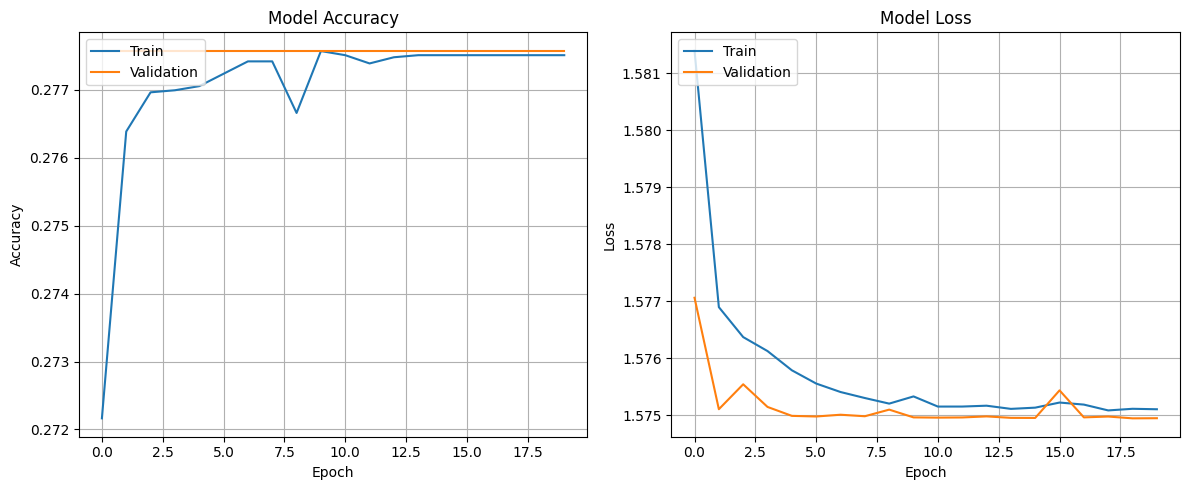


Training plots displayed.


In [6]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

# Plot training & validation loss values
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nTraining plots displayed.")